# Footwear

## Imports

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import os


## config

In [43]:
assets_path = 'assets'
data={
	'angles':{},
	'moments':{},
	'powers':{}
}

## Data Loading

In [44]:
import os
import pandas as pd



for data_type in data.keys():
    for file in os.listdir(assets_path):
        if file.endswith('.csv') and file.startswith(f'{data_type}_'):
            shoe_name = file.replace(f'{data_type}_', '').replace('.csv', '')
            
            df = pd.read_csv(os.path.join(assets_path, file), header=[0,1,4])
            df = df.drop(columns=[('Unnamed: 0_level_0', 'Unnamed: 0_level_1', 'ITEM')])
            df.columns = pd.MultiIndex.from_tuples(df.columns, names=['Stat', 'Metric', 'Axis'])
            
            data[data_type][shoe_name] = df

## Additional Metrics

In [45]:
max_angles={}

for shoe_name,df in data['angles'].items():
    max_angles[shoe_name]= df.max()



## Plotting

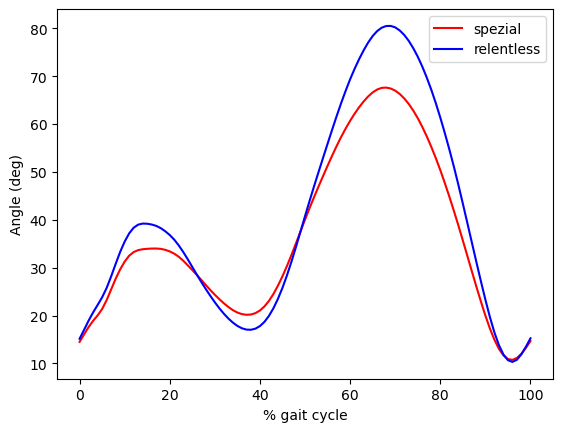

In [46]:

plt.plot(data['angles']['Spezial'][('Mean', 'Left Knee Angles', 'X')], label='spezial',color='red')
plt.plot(data['angles']['Relentless'][('Mean','Left Knee Angles','X')], label='relentless',color='blue')
plt.xlabel('% gait cycle')
plt.ylabel('Angle (deg)')
plt.legend()




<BarContainer object of 101 artists>

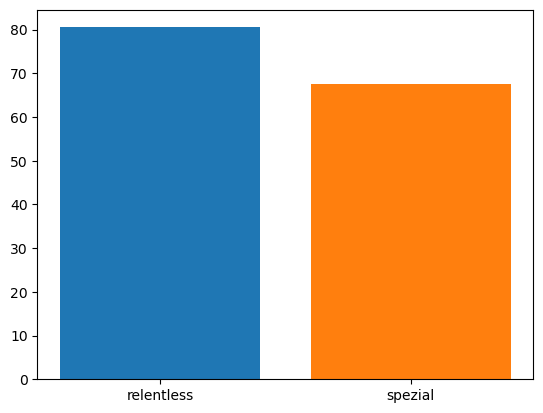

In [47]:
plt.bar(x='relentless', height=(data['angles']['Relentless'][('Mean','Left Knee Angles','X')]))
plt.bar(x='spezial', height=data['angles']['Spezial'][('Mean','Left Knee Angles','X')])